### Calculating the QM solution of the reaction between $OH^-$ and $CH_3Cl$ with ten QM water molecules

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyscf import gto, scf
from pyscf.geomopt.geometric_solver import optimize
import pickle

In [2]:
def move_oh_to_distance(coords, target_distance):

    coords = coords.copy()

    O = 0
    H_oh = 1
    C = 2

    carbon = coords[C]
    oxygen = coords[O]

    # Current direction from C toward O
    direction = oxygen - carbon
    direction /= np.linalg.norm(direction)

    # Preserve the O-H vector
    oh_vector = coords[H_oh] - coords[O]

    # Place O at the desired C-O distance
    new_oxygen = carbon + direction * target_distance

    # Move H together with O
    new_hydrogen = new_oxygen + oh_vector

    coords[O] = new_oxygen
    coords[H_oh] = new_hydrogen

    return coords

def build_molecule(coords):

    atom_string = ""

    for symbol, coord in zip(symbols, coords):

        x, y, z = coord

        atom_string += (
            f"{symbol} "
            f"{x:.10f} "
            f"{y:.10f} "
            f"{z:.10f}\n"
        )

    return gto.M(
        atom=atom_string,
        basis="6-31G",
        charge=-1,
        spin=0,
        unit="Angstrom"
    )
    
def write_constraint(distance):

    with open("constraints.txt", "w") as f:

        f.write("$set\n")
        f.write(
            f"distance 1 3 {distance:.8f}\n"
        )

def make_scf(mol):

    mf = scf.RHF(mol)
    return mf
    
def optimize_at_distance(mol, distance, maxsteps=15):

    # Create the constraint file
    write_constraint(distance)

    # Build RHF + implicit solvent
    mf = make_scf(mol)

    # Optimize geometry while keeping C-O fixed
    mol_opt = optimize(
        mf,
        constraints="constraints.txt",
        maxsteps=maxsteps
    )

    # Recalculate final energy using the optimized geometry
    mf_final = make_scf(mol_opt)
    energy = mf_final.kernel()

    # Return the optimized geometry and energy
    return mol_opt, energy, mf_final

def write_xyz(mol, filename, distance):

    coords = mol.atom_coords(
        unit="Angstrom"
    )

    with open(filename, "w") as f:

        f.write(f"{mol.natm}\n")

        f.write(
            f"C-O distance = {distance:.8f} Angstrom\n"
        )

        for symbol, coord in zip(symbols, coords):

            x, y, z = coord

            f.write(
                f"{symbol:2s} "
                f"{x:14.8f} "
                f"{y:14.8f} "
                f"{z:14.8f}\n"
            )


In [22]:
initial_xyz = """
O   -5.000   0.000   0.000
H   -5.970   0.000   0.000

C    0.000   0.000   0.000
Cl   1.780   0.000   0.000

H   -0.630   0.630   0.630
H   -0.630  -0.630   0.630
H   -0.630   0.000  -0.890

O    0.000   3.000   0.000
H    0.758   3.504   0.000
H   -0.758   3.504   0.000

O    2.500   1.800   0.000
H    2.900   2.400   0.000
H    1.800   2.100   0.000

O   -1.500   2.000   1.500
H   -0.800   2.300   1.700
H   -1.800   2.700   1.300

O    1.500  -2.000   1.500
H    0.800  -2.300   1.700
H    1.800  -2.700   1.300

O   -1.500  -2.000  -1.500
H   -0.800  -2.300  -1.700
H   -1.800  -2.700  -1.300


O    2.000   3.000   0.000
H    2.758   3.504   0.000
H    1.242   3.504   0.000

O    4.500   1.800   0.000
H    4.900   2.400   0.000
H    3.800   2.100   0.000

O    0.500   2.000   1.500
H    1.200   2.300   1.700
H    0.200   2.700   1.300

O    3.500  -2.000   1.500
H    2.800  -2.300   1.700
H    3.800  -2.700   1.300

O    0.500  -2.000  -1.500
H    1.200  -2.300  -1.700
H    0.200  -2.700  -1.300

"""

In [23]:
symbols = [
    "O", "H",
    "C", "Cl",
    "H", "H", "H",

    "O", "H", "H",
    "O", "H", "H",
    "O", "H", "H",
    "O", "H", "H",
    "O", "H", "H",
    "O", "H", "H",
    "O", "H", "H",
    "O", "H", "H",
    "O", "H", "H",
    "O", "H", "H"
]

In [24]:
mol = gto.M(
    atom=initial_xyz,
    basis="6-31G",
    charge=-1,
    spin=0,
    unit="Angstrom"
)

In [25]:
ndistances = 25
distances = np.linspace(3.0, 1.2, ndistances)

print("Number of steps:", len(distances))
print("Starting distance:", distances[0])
print("Final distance:", distances[-1])

Number of steps: 25
Starting distance: 3.0
Final distance: 1.2


In [26]:
os.makedirs("xyz_frames", exist_ok=True)
for f in glob.glob("xyz_frames/frame_*.xyz"):
    os.remove(f)

print("XYZ folder cleared.")

XYZ folder cleared.


In [27]:
energies = []
actual_distances = []
optimized_molecules = []
mean_field_objects = []

current_mol = mol

In [28]:
for i, distance in enumerate(distances):

    print("=" * 70)
    print(f"FRAME {i+1}/"+str(ndistances))
    print(f"Target C-O distance: {distance:.6f} Å")

    # ------------------------------------------------
    # 1. Get previous optimized geometry
    # ------------------------------------------------

    current_coords = current_mol.atom_coords(
        unit="Angstrom"
    )

    # ------------------------------------------------
    # 2. Move OH- to the next reaction-coordinate value
    # ------------------------------------------------

    current_coords = move_oh_to_distance(
        current_coords,
        distance
    )

    # ------------------------------------------------
    # 3. Rebuild PySCF molecule
    # ------------------------------------------------

    current_mol = build_molecule(
        current_coords
    )

    # ------------------------------------------------
    # 4. Constrained solvated optimization
    # ------------------------------------------------

    current_mol, energy, mf = optimize_at_distance(
        current_mol,
        distance)
    
    # ------------------------------------------------
    # 5. Store optimized molecule, energy, and mean field
    # ------------------------------------------------

    optimized_molecules.append(current_mol)
    energies.append(energy)
    mean_field_objects.append(mf)
    
    # ------------------------------------------------
    # 6. Calculate actual C-O distance
    # ------------------------------------------------

    optimized_coords = current_mol.atom_coords(
        unit="Angstrom"
    )

    actual_distance = np.linalg.norm(
        optimized_coords[0] -
        optimized_coords[2]
    )

    actual_distances.append(
        actual_distance
    )

    # ------------------------------------------------
    # 7. Save XYZ
    # ------------------------------------------------

    filename = (
        f"xyz_frames/frame_{i:03d}.xyz"
    )

    write_xyz(
        current_mol,
        filename,
        actual_distance
    )

    # ------------------------------------------------
    # 8. Report
    # ------------------------------------------------

    print(
        f"Actual C-O: "
        f"{actual_distance:.6f} Å"
    )

    print(
        f"Energy: "
        f"{energy:.10f} Hartree"
    )

    print(
        f"Saved: {filename}"
    )

geometric-optimize called with the following command line:
/home/chemistry/venvs/jupyter/lib/python3.14/site-packages/ipykernel_launcher.py -f /home/chemistry/.local/share/jupyter/runtime/kernel-20a16fc1-aa70-4dca-b5b5-42a3cb71d66d.json

                                        ())))))))))))))))/                     
                                    ())))))))))))))))))))))))),                
                                *)))))))))))))))))))))))))))))))))             
                        #,    ()))))))))/                .)))))))))),          
                      #%%%%,  ())))))                        .))))))))*        
                      *%%%%%%,  ))              ..              ,))))))).      
                        *%%%%%%,         ***************/.        .)))))))     
                #%%/      (%%%%%%,    /*********************.       )))))))    
              .%%%%%%#      *%%%%%%,  *******/,     **********,      .))))))   
                .%%%%%%/      *%%%%%%,  **

FRAME 1/25
Target C-O distance: 3.000000 Å


111 internal coordinates being used (instead of 111 Cartesians)
Internal coordinate system (atoms numbered from 1):
Distance 1-3
Distance 1-2
Distance 3-4
Distance 3-5
Distance 3-6
Distance 3-7
Distance 4-11
Distance 8-9
Distance 8-10
Distance 9-25
Distance 11-12
Distance 11-13
Distance 11-23
Distance 12-23
Distance 12-28
Distance 13-23
Distance 14-15
Distance 14-16
Distance 17-18
Distance 17-19
Distance 20-21
Distance 20-22
Distance 23-24
Distance 23-25
Distance 26-27
Distance 26-28
Distance 29-30
Distance 29-31
Distance 32-33
Distance 32-34
Distance 35-36
Distance 35-37
Angle 4-3-5
Angle 4-3-6
Angle 4-3-7
Angle 5-3-6
Angle 5-3-7
Angle 6-3-7
Angle 3-4-11
Angle 9-8-10
Angle 8-9-25
Angle 4-11-23
Angle 13-11-23
Angle 11-12-28
Angle 11-13-23
Angle 15-14-16
Angle 18-17-19
Angle 21-20-22
Angle 11-23-25
Angle 13-23-25
Angle 24-23-25
Angle 9-25-23
Angle 27-26-28
Angle 30-29-31
Angle 33-32-34
Angle 36-35-37
LinearAngleX 4-11-12
LinearAngleY 4-11-12
LinearAngleX 23-12-28
LinearAngleY 23-12-28
L


Geometry optimization cycle 1
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   O  -3.000000   0.000000   0.000000    0.000000  0.000000  0.000000
   H  -3.970000   0.000000   0.000000    0.000000  0.000000  0.000000
   C   0.000000   0.000000   0.000000    0.000000  0.000000  0.000000
  Cl   1.780000   0.000000   0.000000    0.000000  0.000000  0.000000
   H  -0.630000   0.630000   0.630000    0.000000  0.000000  0.000000
   H  -0.630000  -0.630000   0.630000    0.000000  0.000000  0.000000
   H  -0.630000   0.000000  -0.890000    0.000000  0.000000  0.000000
   O   0.000000   3.000000   0.000000    0.000000  0.000000  0.000000
   H   0.758000   3.504000   0.000000    0.000000  0.000000  0.000000
   H  -0.758000   3.504000   0.000000    0.000000  0.000000  0.000000
   O   2.500000   1.800000   0.000000    0.000000  0.000000  0.000000
   H   2.900000   2.400000   0.000000    0.000000  0.000000  0.000000
   H   1.800000   2.100000   0.0

Step    0 : Gradient = 4.578e-01/1.367e+00 (rms/max) Energy = -1331.1261291697
Hessian Eigenvalues: 2.30000e-02 2.30000e-02 2.30000e-02 ... 1.34858e+00 1.38280e+00 1.67782e+00


...


Geometry optimization cycle 15
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   O  -1.223608   0.025122  -1.522299   -0.000102 -0.000313 -0.002580
   H  -1.948662  -0.087530  -2.120977   -0.000400 -0.001109 -0.002091
   C  -0.104717  -0.182794  -1.902896   -0.000090  0.000255 -0.002852
  Cl   3.457618  -0.148733  -2.638641   -0.000317  0.000045 -0.000234
   H   0.613467  -0.098637  -1.099036    0.000015  0.001397 -0.003069
   H   0.078839  -1.182135  -2.303483    0.000564  0.000085 -0.002113
   H   0.270841   0.500025  -2.669018   -0.000698 -0.000024 -0.003416
   O   0.526628   4.163573  -0.351483   -0.000453 -0.000378  0.001257
   H   1.237113   3.649228  -0.743253   -0.000536 -0.000084  0.000732
   H  -0.229094   3.610494  -0.166589   -0.000421 -0.000504  0.000978
   O   2.615891   2.249576  -0.715388   -0.000549 -0.000328  0.000445
   H   2.292252   1.803617   0.069732   -0.000359 -0.000743  0.000267
   H   2.887977   1.623371  -1.

Step   14 : Displace = 1.999e-03/5.878e-03 (rms/max) Trust = 3.000e-01 (=) Grad_T = 3.221e-05/7.483e-05 (rms/max) E (change) = -1334.5616588878 (-6.981e-07) Quality = 1.404
Hessian Eigenvalues: 1.22212e-03 6.42665e-03 1.37754e-02 ... 5.85120e-01 5.90563e-01 1.13296e+00



Geometry optimization cycle 16
Cartesian coordinates (Angstrom)
 Atom        New coordinates             dX        dY        dZ
   O  -1.223456   0.025663  -1.525233    0.000152  0.000541 -0.002933
   H  -1.948689  -0.087762  -2.123564   -0.000027 -0.000232 -0.002586
   C  -0.104673  -0.182471  -1.906029    0.000044  0.000324 -0.003132
  Cl   3.458335  -0.148891  -2.638825    0.000717 -0.000158 -0.000185
   H   0.613849  -0.097379  -1.102596    0.000381  0.001258 -0.003560
   H   0.079190  -1.182109  -2.305775    0.000351  0.000026 -0.002292
   H   0.270589   0.499651  -2.672922   -0.000253 -0.000374 -0.003904
   O   0.526117   4.163208  -0.349736   -0.000511 -0.000364  0.001748
   H   1.236303   3.648845  -0.742028   -0.000810 -0.000383  0.001225
   H  -0.229767   3.610362  -0.164895   -0.000673 -0.000132  0.001694
   O   2.615596   2.249208  -0.715054   -0.000295 -0.000368  0.000334
   H   2.291950   1.803162   0.070021   -0.000302 -0.000455  0.000288
   H   2.888138   1.623159  -1.

Step   15 : Displace = 2.255e-03/6.924e-03 (rms/max) Trust = 3.000e-01 (=) Grad_T = 2.416e-05/5.237e-05 (rms/max) E (change) = -1334.5616595937 (-7.059e-07) Quality = 1.390
Hessian Eigenvalues: 1.22212e-03 6.42665e-03 1.37754e-02 ... 5.85120e-01 5.90563e-01 1.13296e+00
Maximum iterations reached (15); increase --maxiter for more


Geometry optimization failed to converge in 15 iterations
converged SCF energy = -1334.56165959373
Actual C-O: 1.200000 Å
Energy: -1334.5616595937 Hartree
Saved: xyz_frames/frame_024.xyz


### Visualizing some results

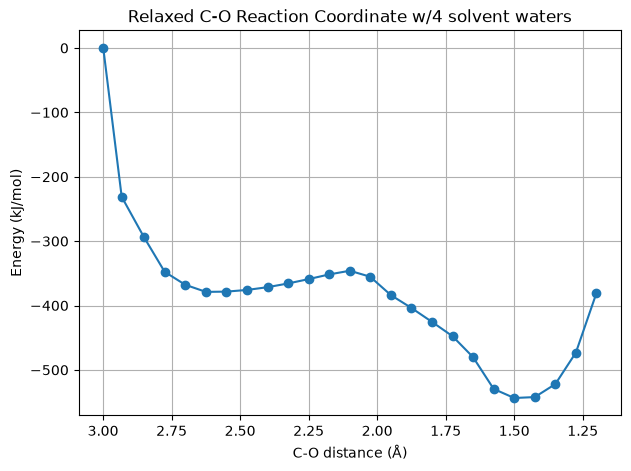

In [29]:
# Looking at the energies
energies_kj=(energies-energies[0])*2626
plt.figure(figsize=(7,5))
plt.plot(actual_distances,energies_kj,marker="o")
plt.gca().invert_xaxis()
xlabel = "C-O distance (Å)"; plt.xlabel(xlabel)
ylabel = "Energy (kJ/mol)"
plt.ylabel(ylabel)
plt.title("Relaxed C-O Reaction Coordinate w/4 solvent waters")
plt.grid(True)
plt.show()

### Saving additional results

In [30]:
# Saves the optimized molecule objects
with open("optimized_mols.pkl", "wb") as f:
    pickle.dump(optimized_molecules, f)

with open("optimized_mfs.pkl", "wb") as f:
    pickle.dump(mean_field_objects, f)
    
# Save the relative energies as a text file
data = np.array([actual_distances,energies_kj]).T; print(np.shape(data))
np.savetxt('energy.txt',data,header=xlabel+', '+ylabel)

# Save the absolute energies as a text file
data = np.array([actual_distances,energies]).T; print(np.shape(data))
np.savetxt('energy_abs.txt',data,header=xlabel+', '+"Relative energy (Hartree)")

(25, 2)
(25, 2)
